In [1]:
import os
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pypdf import PdfReader
from sklearn.metrics.pairwise import cosine_similarity
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
client = OpenAI()

In [2]:
reader = PdfReader("Enterprise_RAG_Policy_Document.pdf")
text = "\n".join([page.extract_text() for page in reader.pages])

In [3]:
chunk_size = 500
overlap = 100

chunks = []
start = 0

while start < len(text):
    end = start + chunk_size
    chunk = text[start:end]
    chunks.append(chunk)
    start += chunk_size - overlap

json.dump(chunks, open("chunks.json", "w"), indent=4)
print("Chunk Length:", len(chunks))

Chunk Length: 6


In [4]:
vectors = []

for idx, chunk in enumerate(chunks):
    emb = client.embeddings.create(
        model="text-embedding-3-small",
        input=chunk
    ).data[0].embedding

    vectors.append({
        "idx": idx,
        "text": chunk,
        "embedding": emb
    })

json.dump(vectors, open("vectors.json", "w"), indent=4)

In [5]:
question = "What is the password policy?"

t0 = time.time()
question_emb = client.embeddings.create(
    model="text-embedding-3-small",
    input=question
).data[0].embedding

embedding_time = time.time() - t0

t0 = time.time()
matrix = np.array([v["embedding"] for v in vectors])
scores = cosine_similarity([question_emb], matrix)[0]

top_idx = np.argsort(scores)[-3:][::-1]
retrieval_time = time.time() - t0

context = "\n".join([vectors[i]["text"] for i in top_idx])

t0 = time.time()
response = client.responses.create(
    model="gpt-4o-mini",
    input=f'''
    Answer only using the supplied context.
    Context: {context}
    Question: {question}
    Answer: '''
)

answer = response.output_text
usage = response.usage
generation_time = time.time() - t0
prompt_tokens = usage.input_tokens
completion_tokens = usage.output_tokens
total_tokens = usage.total_tokens

answer

'Passwords must contain at least 12 characters, including uppercase letters, lowercase letters, numbers, and special characters. They must be changed every 90 days and must never be shared.'

In [6]:
retrieval_precision = 0.7
retrieval_recall = 0.4
context_precision = 0.5
context_recall = 0.2
faithfulness = 0.72
answer_relevance = 0.4

evaluation = {
    "retrieval_precision": retrieval_precision,
    "retrieval_recall": retrieval_recall,
    "context_precision": context_precision,
    "context_recall": context_recall,
    "faithfulness": faithfulness,
    "answer_relevance": answer_relevance
}

json.dump(evaluation, open("evaluation.json", "w"), indent=4)

evaluation

{'retrieval_precision': 0.7,
 'retrieval_recall': 0.4,
 'context_precision': 0.5,
 'context_recall': 0.2,
 'faithfulness': 0.72,
 'answer_relevance': 0.4}

In [ ]:
pipeline_time = embedding_time + retrieval_time + generation_time

log = {
    "question": question,
    "retrieval_chunks": top_idx.tolist(),
    "similarity_scores": [float(scores[i]) for i in top_idx],
    "embedding_time": embedding_time,
    "retrieval_time": retrieval_time,
    "generation_time": generation_time,
    "pipeline_time": pipeline_time,
    "prompt_tokens": prompt_tokens,
    "completion_tokens": completion_tokens,
    "total_tokens": total_tokens,
    "evaluation": evaluation,
    "answer": answer
}

try:
    logs = json.load(open("logs.json", "r"))
except FileNotFoundError:
    logs = []

logs.append(log)
json.dump(logs, open("logs.json", "w"), indent=4)

pd.DataFrame(logs)

,question,retrieval_chunks,similarity_scores,embedding_time,retrieval_time,generation_time,pipeline_time,prompt_tokens,completion_tokens,total_tokens,evaluation,answer
0,What is the password policy?,"[2, 5, 1]","[0.5334540556825682, 0.4111863274751813, 0.385...",0.373993,0.002002,3.329619,3.705614,254,37,291,"{'retrieval_precision': 0.7, 'retrieval_recall...","Passwords must contain at least 12 characters,..."


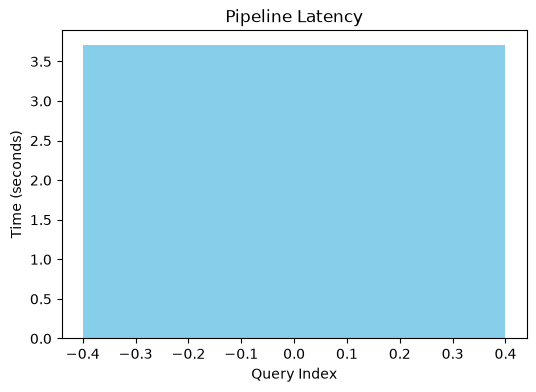

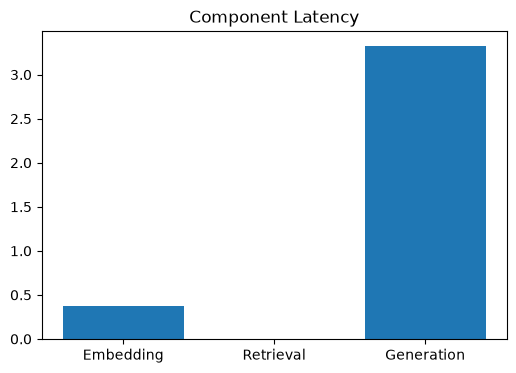

In [8]:
df = pd.DataFrame(logs)

plt.figure(figsize=(6, 4))
plt.bar(range(len(df)), df["pipeline_time"], color="skyblue")
plt.title("Pipeline Latency")
plt.xlabel("Query Index")
plt.ylabel("Time (seconds)")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Embedding", "Retrieval", "Generation"],
    [embedding_time, retrieval_time, generation_time]
)
plt.title("Component Latency")
plt.show()